In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
import pandas as pd

# 1. Import Dataset — loads directly from internet, no file needed
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv",
                 names=['Pregnancies','Glucose','BloodPressure','SkinThickness',
                        'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'])

print("Dataset loaded:", df.shape)
df.head()  # shows first 5 rows as a table

Dataset loaded: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# 2. Clean the Data
cols_to_fix = ['Glucose', 'BloodPressure', 'BMI', 'Insulin']
for col in cols_to_fix:
    df[col] = df[col].replace(0, df[col].mean())

print("Cleaned! Zero values replaced with column averages.")
print(df.isnull().sum())  # should show 0 missing values

Cleaned! Zero values replaced with column averages.
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 3. Split features and label
X = df.drop('Outcome', axis=1)   # input features (8 columns)
y = df['Outcome']                 # what we're predicting

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Train the Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("\nModel trained successfully!")

# 5. Test the Model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Training samples: 614
Testing samples: 154

Model trained successfully!
Model Accuracy: 76.62%


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Prediction: Diabetes — YES


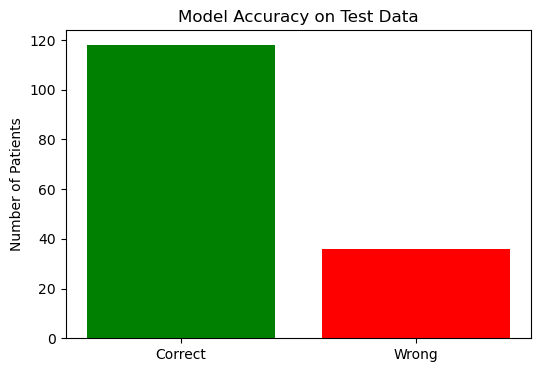

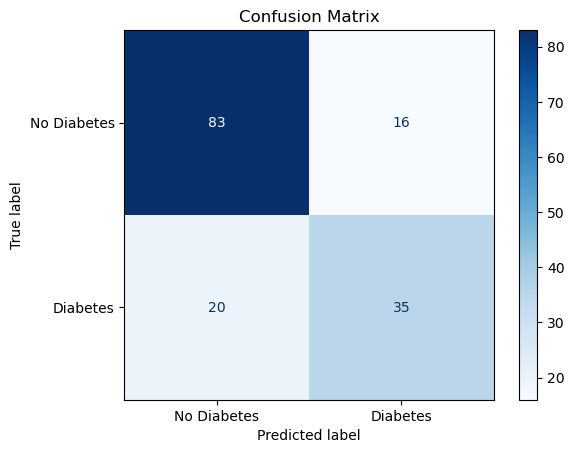

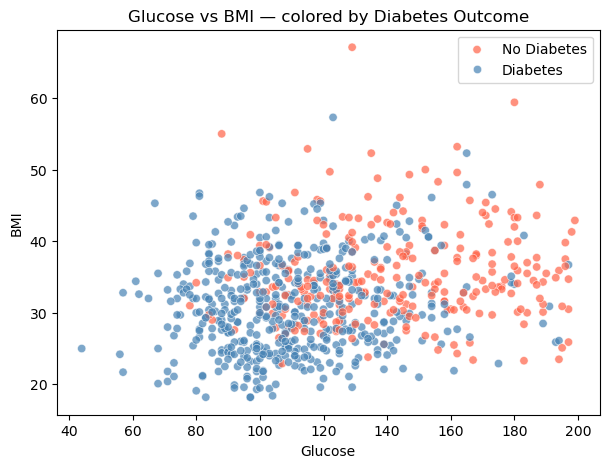

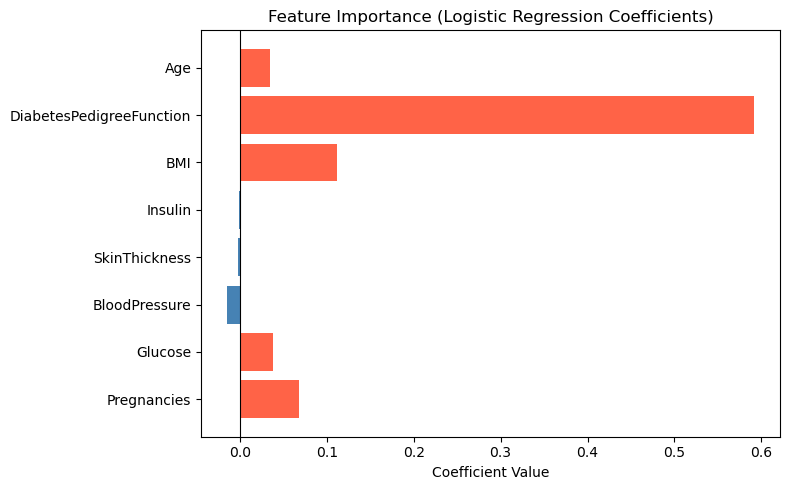

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 6. Predict on a new patient
# [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, DiabetesPedigree, Age]
new_patient = [[2, 180, 74, 24, 0, 28.0, 0.5, 45]]
result = model.predict(new_patient)

if result[0] == 1:
    print("Prediction: Diabetes — YES")
else:
    print("Prediction: Diabetes — NO")

# --- Visual 1: Accuracy Bar Chart ---
correct = int(accuracy * len(y_test))
wrong = len(y_test) - correct
plt.figure(figsize=(6, 4))
plt.bar(['Correct', 'Wrong'], [correct, wrong], color=['green', 'red'])
plt.title('Model Accuracy on Test Data')
plt.ylabel('Number of Patients')
plt.savefig('accuracy.png')
plt.show()

# --- Visual 2: Confusion Matrix ---
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# --- Visual 3: Glucose vs BMI Scatter Plot ---
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome',
                palette={0: 'steelblue', 1: 'tomato'}, alpha=0.7)
plt.title('Glucose vs BMI — colored by Diabetes Outcome')
plt.legend(labels=['No Diabetes', 'Diabetes'])
plt.savefig('glucose_vs_bmi.png')
plt.show()

# --- Visual 4: Feature Importance ---
import numpy as np
feature_names = X.columns
coefficients = model.coef_[0]
colors = ['tomato' if c > 0 else 'steelblue' for c in coefficients]
plt.figure(figsize=(8, 5))
plt.barh(feature_names, coefficients, color=colors)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [6]:
import pandas as pd

# 1. Import Dataset — loads directly from internet, no file needed
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv",
                 names=['Pregnancies','Glucose','BloodPressure','SkinThickness',
                        'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'])

print("Dataset loaded:", df.shape)
df.head()  # shows first 5 rows as a table

Dataset loaded: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Saved: diabetes_dashboard.png


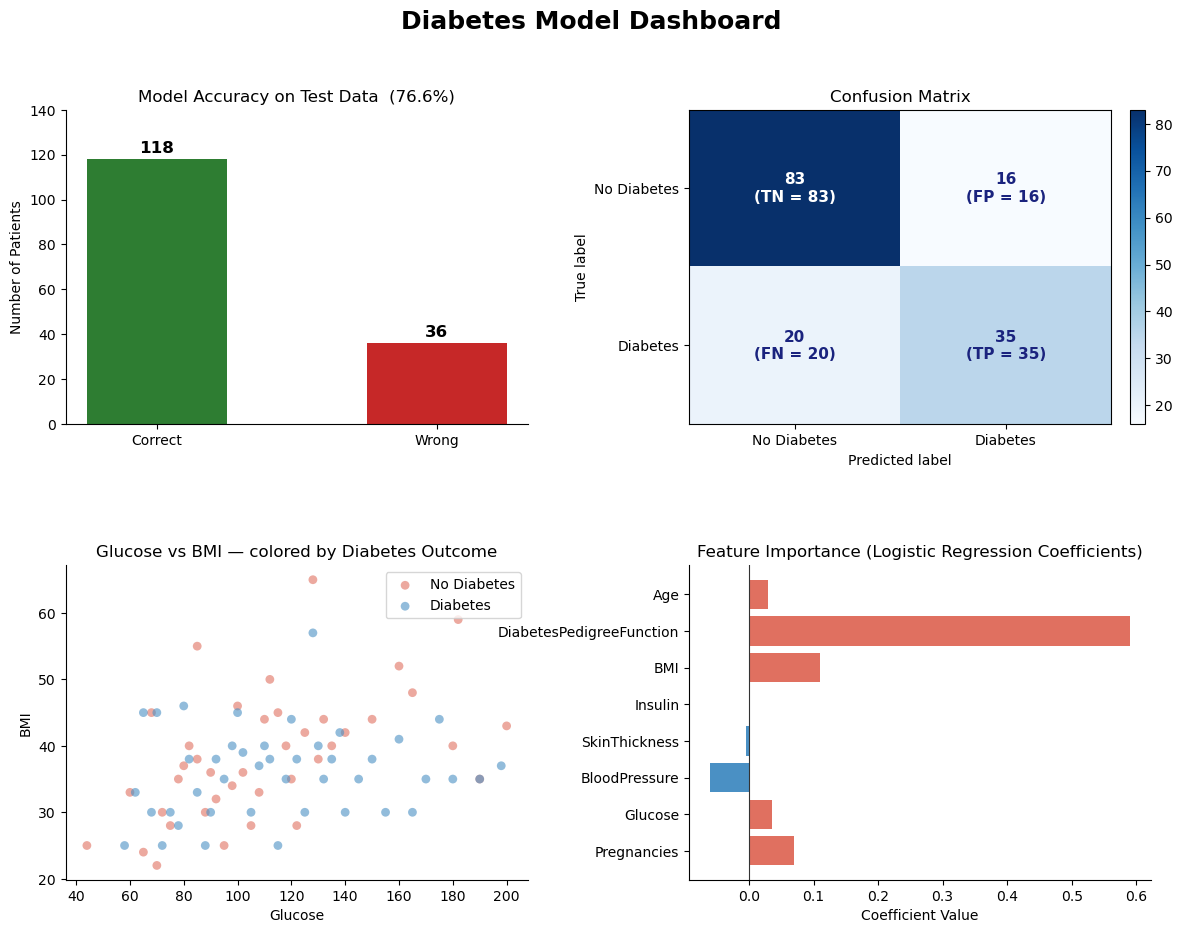

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
correct, wrong = 118, 36
total = correct + wrong
accuracy = correct / total * 100

# Confusion matrix  [TN, FP], [FN, TP]
cm = np.array([[83, 16],
               [20, 35]])

# Feature importance (logistic regression coefficients)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
coeffs   = [0.07, 0.035, -0.06, -0.005, 0.001, 0.11, 0.59, 0.03]

# Glucose vs BMI sample data  [glucose, bmi]
no_diab = np.array([[44,25],[60,33],[65,24],[68,45],[70,22],[72,30],[75,28],[78,35],
                    [80,37],[82,40],[85,38],[85,55],[88,30],[90,36],[92,32],[95,25],
                    [98,34],[100,46],[102,36],[105,28],[108,33],[110,44],[112,50],
                    [115,45],[118,40],[120,35],[122,28],[125,42],[128,65],[130,38],
                    [132,44],[135,40],[140,42],[150,44],[160,52],[165,48],[180,40],
                    [182,59],[190,35],[200,43]])
diab    = np.array([[58,25],[62,33],[65,45],[68,30],[70,45],[72,25],[75,30],[78,28],
                    [80,46],[82,38],[85,33],[88,25],[90,30],[92,38],[95,35],[98,40],
                    [100,45],[102,39],[105,30],[108,37],[110,40],[112,38],[115,25],
                    [118,35],[120,44],[122,38],[125,30],[128,57],[130,40],[132,35],
                    [135,38],[138,42],[140,30],[145,35],[150,38],[155,30],[160,41],
                    [165,30],[170,35],[175,44],[180,35],[190,35],[198,37]])

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Diabetes Model Dashboard', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── Chart 1 : Model Accuracy ─────────────────────────────────────────────
bars = ax1.bar(['Correct', 'Wrong'], [correct, wrong],
               color=['#2e7d32', '#c62828'], width=0.5, edgecolor='none')
for bar, val in zip(bars, [correct, wrong]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_title(f'Model Accuracy on Test Data  ({accuracy:.1f}%)', fontsize=12)
ax1.set_ylabel('Number of Patients')
ax1.set_ylim(0, 140)
ax1.spines[['top','right']].set_visible(False)

# ── Chart 2 : Confusion Matrix ───────────────────────────────────────────
im = ax2.imshow(cm, cmap='Blues', aspect='auto')
labels = [['TN = 83', 'FP = 16'], ['FN = 20', 'TP = 35']]
colors = [['white', '#1a237e'], ['#1a237e', 'white']]
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i,j]}\n({labels[i][j]})',
                 ha='center', va='center', fontsize=11,
                 color='white' if cm[i,j] > 50 else '#1a237e', fontweight='bold')
ax2.set_xticks([0,1]); ax2.set_xticklabels(['No Diabetes', 'Diabetes'])
ax2.set_yticks([0,1]); ax2.set_yticklabels(['No Diabetes', 'Diabetes'])
ax2.set_xlabel('Predicted label'); ax2.set_ylabel('True label')
ax2.set_title('Confusion Matrix', fontsize=12)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

# ── Chart 3 : Glucose vs BMI Scatter ─────────────────────────────────────
ax3.scatter(no_diab[:,0], no_diab[:,1], c='#e07060', alpha=0.6,
            s=40, label='No Diabetes', edgecolors='none')
ax3.scatter(diab[:,0], diab[:,1], c='#4a90c4', alpha=0.6,
            s=40, label='Diabetes', edgecolors='none')
ax3.set_xlabel('Glucose'); ax3.set_ylabel('BMI')
ax3.set_title('Glucose vs BMI — colored by Diabetes Outcome', fontsize=12)
ax3.legend(loc='upper right', framealpha=0.8)
ax3.spines[['top','right']].set_visible(False)

# ── Chart 4 : Feature Importance ─────────────────────────────────────────
colors_fi = ['#e07060' if c >= 0 else '#4a90c4' for c in coeffs]
bars4 = ax4.barh(features, coeffs, color=colors_fi, edgecolor='none')
ax4.axvline(0, color='#333', linewidth=0.8)
ax4.set_xlabel('Coefficient Value')
ax4.set_title('Feature Importance (Logistic Regression Coefficients)', fontsize=12)
ax4.spines[['top','right']].set_visible(False)

plt.savefig('diabetes_dashboard.png', dpi=150, bbox_inches='tight')
print("Saved: diabetes_dashboard.png")
plt.show()